
# Tutorial Outline: Spectral Embedding Methods

## 1. Introduction

* **Motivation:**

  * Mass spectra are sparse, high-dimensional signals.
  * To analyze them efficiently, we need to transform spectra into lower-dimensional, machine-readable embeddings.
* **Learning Goals:**

  * Understand X approaches to spectral embedding.
  * See how dimensionality reduction and embeddings enable clustering, visualization, and downstream ML tasks.

---

## 2. Method 1: Spectral Hashing

### 2.1 Conceptual Introduction

* Required Reading: https://pubs.acs.org/doi/full/10.1021/acs.jproteome.9b00291
* Begin with **clustering in 2D**: show how points close together can be grouped.
* Extend to **3D embeddings** as an example of higher-dimensional clustering.
* Transition: spectra are naturally high-dimensional; embeddings allow efficient clustering.

### 2.2 From Peaks to Vectors

* Represent a spectrum as a list of *m/z*–intensity pairs.
* Traditional binning: divide the *m/z* axis into bins and assign intensities.
* Limitation: When binning, you have to take a **continuous value** (m/z) and transform it to a **discrete value**. This presents two problems
  * Information is lost! Small differences in the m/z dimension can give very imporant information
  * The same peak can extend across multiple bins. Imagine a peak that is located precisely at 999.999 m/z. Depending on how well/poorly the instrument is calibrated, the same peak can be sorted into different bins
  * To demonstrate this, show how feature hashing fails to differentiate between TMT channels

### 2.3 Feature Hashing for Spectral Embedding

* Use **feature hashing** to map high-resolution bins into a fixed-length vector (e.g., 800 dimensions).
* Each *m/z* bin is hashed into one of the vector’s components, accumulating intensity.
* Benefits:

  * Compact vector representation.
  * Preserves similarity structure for clustering or approximate nearest neighbor (ANN) search.

---

## 3. Method 2: Positional Embedding of Peaks

### 3.1 Motivation

* Required Reading: https://www.nature.com/articles/s41467-024-49731-x
* Simple hashing and binning ignore relative *m/z* spacing.
* Many deep learning models require dense, continuous representations.

### 3.2 Encoding Strategy

* Apply **sinusoidal positional encoding** to each peak’s *m/z* value.
* Each peak is mapped to a **512-dimensional vector**.
* Intensities can be incorporated as additional features or scaling factors.

### 3.3 Applications

* Captures fine-grained relationships between peaks.
* Useful as input to transformer or deep learning architectures for spectral analysis.

---

## 4. Method 3: Positional Embedding of Augmented Spectra

### 4.1 Motivation

* Required Reading: https://www.nature.com/articles/s41592-025-02718-y
* Relevant signal spans multiple spectra: across retention time (RT) and between MS1 and MS2 levels.
* A richer representation is needed to capture this context.

### 4.2 2D Positional Encoding

* Represent each peak as a tuple: (*m/z*, intensity, RT offset, MS level).
* Apply **2D sinusoidal embeddings** to jointly encode *m/z* and RT.
* Concatenate with learned embeddings for intensity and spectrum level.
* Output: a **512-dimensional embedding** for each peak in the augmented spectrum.



Below, you'll find some code to get you started. (Code was mostly taken from https://colab.research.google.com/drive/13WEV58HpkY7f0kFi2BA5ia5p0XZCL3Cq?authuser=1#scrollTo=FYgmwfThBQJJ)

In [49]:
# @title Run this cell to install necessary python packages
""" %%capture
!pip install gdown
!pip install pyteomics==4.6.1
!pip install plotly==5.18.0
!pip install pandas
!pip install spectrum_utils==0.4.2 """

' %%capture\n!pip install gdown\n!pip install pyteomics==4.6.1\n!pip install plotly==5.18.0\n!pip install pandas\n!pip install spectrum_utils==0.4.2 '

In [50]:
import spectrum_utils.plot as sup
import spectrum_utils.spectrum as sus
import pyteomics
from pyteomics import mzml, auxiliary
import gdown
import plotly.io as pio
import plotly.tools as tls
import plotly.graph_objects as go
import pandas as pd
import random
import numpy as np

In [51]:
# @title Run this cell to create our amino acid dictionary (from Lesson 1).
aa_mass = {'A': 71.037114, 'R':156.101111 , 'N': 114.042927,
           'D': 115.026943, 'C': 103.009185, 'E': 129.042593,
           'Q' : 128.058578, 'G': 57.021464, 'H': 137.058912,
           'I': 113.084064, 'L': 113.084064, 'K': 128.094963,
           'M' : 131.040485, 'F':  147.068414, 'P':  97.052764,
           'S': 87.032028, 'T': 101.047679, 'U': 150.95363,
           'W': 186.079313, 'Y': 163.06332, 'V': 99.068414}

In [52]:
# @title Run this cell to declare a function that creates a b-/y-ion ladder for a peptide.

# This will make a b/y ion ladder for any given peptide and put it in a dataframe
def make_ion_ladder(peptide, aa_mass):
    b_ions = {}
    y_ions = {}

    mass_Hydrogen = 1.0078
    mass_Oxygen = 15.994915
    proton_mass = 1.007

    '''
    Note: In the following functions, if you look closely to the calculations,
    you will see some additions of protons that are different to what we did in
    lesson 1 & 2. This is because instead of enzymatically digesting a protein,
    we are violently fragmenting the peptides milliseconds before measuring them.
    The physics is a little more complicated, so don't worry too much about it.

    If you really want to know the chemistry/physics behind this, you can read
    about it in this paper: https://cse.sc.edu/~rose/790B/papers/dancik.pdf
    '''
    # Generate b-ions
    b_mass_current = 0
    b_ion = ''
    fragment = 0
    for aa in peptide:
        b_ion += aa
        if (b_ion != peptide):
          b_mass_current += aa_mass[aa]
          b_ions[b_ion] = b_mass_current + proton_mass # mass of the charge on fragment

    # Generate y-ions
    y_mass_current = mass_Hydrogen + mass_Oxygen #adds terminal OH
    y_mass_current += proton_mass
    y_ion = ''
    fragment = 0
    for aa in peptide[::-1]:
        y_ion += aa
        if (y_ion[::-1] != peptide):
          y_mass_current += aa_mass[aa]
          y_ions[y_ion[::-1]] = y_mass_current + proton_mass #mass of charge on fragment

    # Populate dataframe
    data = {
        'b#': [b+1 for b in range(len(peptide)-1)],
        'b_ion_m/z': [b_ions[b_key] for b_key in b_ions.keys()],
        'b_ion_sequence': [b_key for b_key in b_ions.keys()],
        'y_ion_sequence': [y_key for y_key in y_ions.keys()][::-1],
        'y_ion_m/z': [y_ions[y_key] for y_key in y_ions.keys()][::-1],
        'y#': [len(peptide)-i-1 for i in range(len(peptide)-1)]
    }

    # Format dataframe
    df = pd.DataFrame(data)
    # df = df.style.set_properties(
    #     subset=['b_ion_sequence'],
    #     **{'text-align': 'left'}
    # ).format({
    #     'b_ion_m/z': '{:,.2f}',
    #     'y_ion_m/z': '{:,.2f}'
    # }).set_table_styles([{
    #     'selector': 'thead th',
    #     'props': [('vertical-align', 'bottom'), ('text-align', 'left')]
    # }, {
    #     'selector': 'th.index_name',  # targeting the index name specifically
    #     'props': [('vertical-align', 'bottom')]
    # }])

    # print(df)
    return(df)

In [53]:
# @title Run this cell to declare a function that gets an MS2 spectrum object.

def get_MS2_object(mzml_path, scan, peptide = None):
    su_spectrum = None
    with pyteomics.mzml.read(mzml_path) as spectra:
        for spectrum in spectra:
            scanNumber = int(spectrum['id'].split('=')[-1])
            if scanNumber == scan:
                # This finds the cooresponding values in the .mzml file to create our MS2
                spectrum_id = spectrum['id']
                mz = spectrum['m/z array']
                intensity = spectrum['intensity array']
                retention_time = spectrum['scanList']['scan'][0]['scan start time']
                precursor_mz = spectrum['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']
                precursor_charge = int(spectrum['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['charge state'])

                su_spectrum = sus.MsmsSpectrum(spectrum_id, precursor_mz, precursor_charge, mz, intensity, retention_time=retention_time)

                # Process the spectrum
                su_spectrum = (su_spectrum.filter_intensity(0.05, 100)
                               .remove_precursor_peak(fragment_tol_mass=0.5, fragment_tol_mode='Da')
                               .scale_intensity('root'))
                break
    # Formatting
    if su_spectrum:
        fragment_tol_mass = 0.5
        fragment_tol_mode = 'Da'  ## for some reason, if I use 'ppm' it doesn't work

        # If given the peptide, spec_utils can annotate the peaks
        if peptide:
          su_spectrum = su_spectrum.annotate_proforma(peptide, fragment_tol_mass, fragment_tol_mode, ion_types='by', max_ion_charge=2)
    return su_spectrum

In [54]:
# @title Run this cell to declare a function that plots an MS2 spectrum.

def plot_MS2(ms2_spectrum):
    ax = sup.spectrum(ms2_spectrum)
    plotly_fig = tls.mpl_to_plotly(ax.figure)
    plotly_fig['layout']['plot_bgcolor'] = 'white'
    plotly_fig['layout']['xaxis']['showline'] = True
    plotly_fig['layout']['xaxis']['linecolor'] = 'black'
    plotly_fig['layout']['xaxis']['linewidth'] = 2
    plotly_fig['layout']['yaxis']['linecolor'] = 'black'
    plotly_fig['layout']['yaxis']['linewidth'] = 2
    plotly_fig.show()

In [55]:
# This function is defined above in Part 1 - take a look at the code up
#   there to see what it is doing
make_ion_ladder('VLDALDSIK', aa_mass)

,b#,b_ion_m/z,b_ion_sequence,y_ion_sequence,y_ion_m/z,y#
0,1,100.075414,V,LDALDSIK,874.486898,8
1,2,213.159478,VL,DALDSIK,761.402834,7
2,3,328.186421,VLD,ALDSIK,646.375891,6
3,4,399.223535,VLDA,LDSIK,575.338777,5
4,5,512.307599,VLDAL,DSIK,462.254713,4
5,6,627.334542,VLDALD,SIK,347.227770,3
6,7,714.366570,VLDALDS,IK,260.195742,2
7,8,827.450634,VLDALDSI,K,147.111678,1


In [56]:
mzml_path = '04-17-23_CA_Tryp_HCD_10min_CLEAN.mzML'
ms2_spectrum_unannotated = get_MS2_object(mzml_path, 5672)
plot_MS2(ms2_spectrum_unannotated)

In [57]:
ms2_spectrum_annotated = get_MS2_object(mzml_path, 5672, peptide = 'VLDALDSIK')
plot_MS2(ms2_spectrum_annotated)

![Each m/z value, m_j, is projected into 512 dimensions](CasanovoEncoding.png)

Positional encoding, as outlined in the Casanovo paper. D = 512

In [58]:
# Define positional encoding function used by Casanovo
# This function takes in 1 m/z value and returns a 512-dimensional positional encoding vector
# (this feels sort of like a reverse Fourier transform)
def positional_encoding(m_z, d_model = 512, lambda_min = 0.001, lambda_max = 10000):
    encoding = np.zeros(d_model)
    d_sin = int(d_model/2)
    d_cos = d_model - d_sin
    for d in range(d_sin):
        encoding[d] = np.sin(m_z / ( (lambda_min / (2 * np.pi) ) * (lambda_max / lambda_min)**(d/(d_sin - 1))))
    for d in range(d_sin, d_model):
        encoding[d] = np.cos(m_z / ( (lambda_min / (2 * np.pi) ) * (lambda_max / lambda_min)**((d - d_sin ) / (d_cos - 1))))
    return encoding


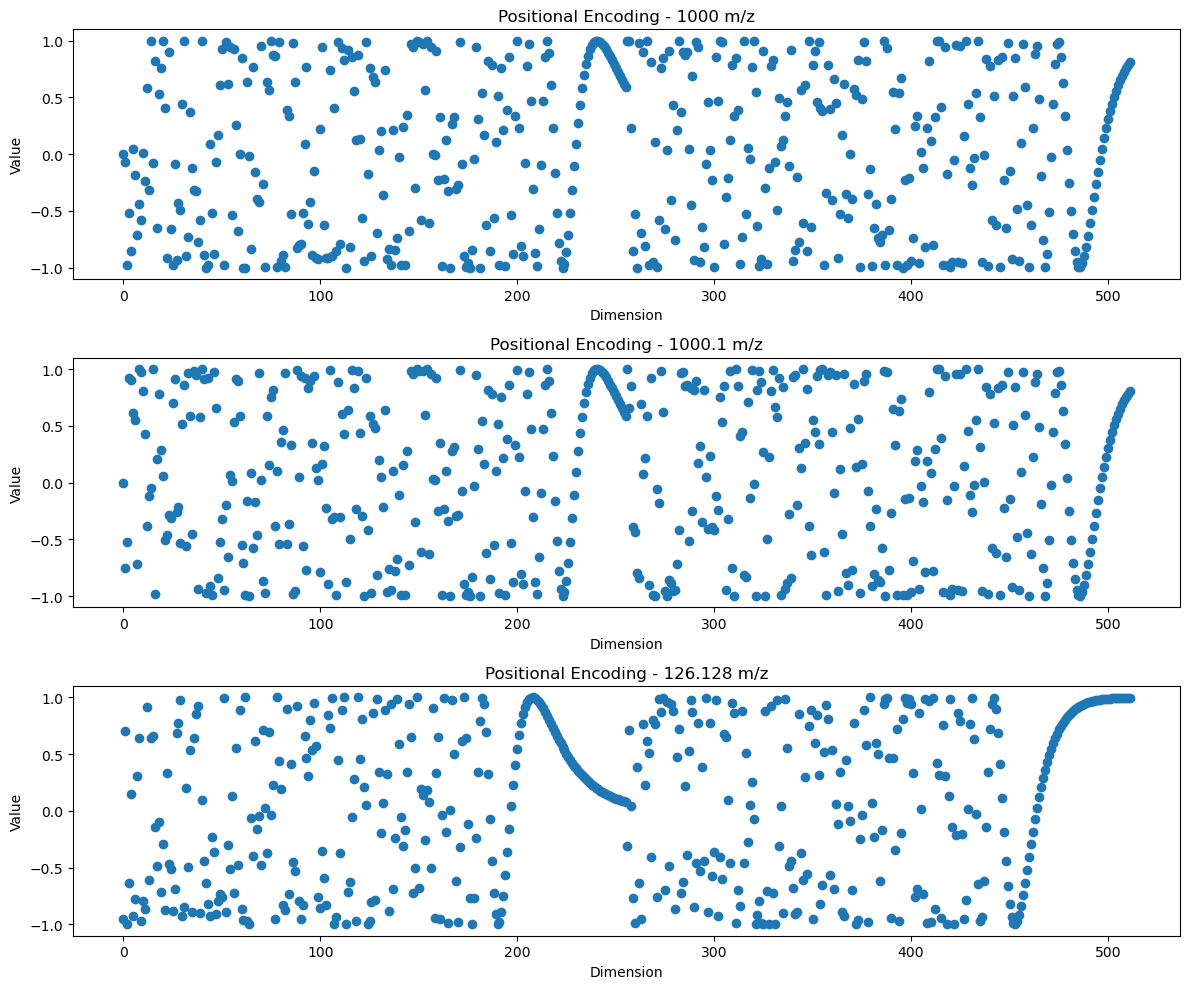

In [ ]:
encode_1 = positional_encoding(1000)
encode_2 = positional_encoding(1000.1)
encode_3 = positional_encoding(126.1277)
# plot the encodings as three scatter plots,
import matplotlib.pyplot as plt

# Set the figure size before creating subplots
plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.scatter(range(len(encode_1)), encode_1)
plt.title("Positional Encoding - 1000 m/z")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.subplot(3, 1, 2)
plt.scatter(range(len(encode_2)), encode_2)
plt.title("Positional Encoding - 1000.1 m/z")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.subplot(3, 1, 3)
plt.scatter(range(len(encode_3)), encode_3)
plt.title("Positional Encoding - 126.128 m/z")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.tight_layout()
plt.show()


I only halfway understand what's going on here, so the following explanation should be taken with a grain of salt

The positional encoding attempts to capture both high-resolution information and low-resolution information. 

Dimensions ~200-255 and ~450-500 capture low resolution information. They will only differ if there is a large m/z difference between the encoded values. 

Dimensions 0-50 and 256-300 encoded high resolution information. They change even if the m/z values are very close together

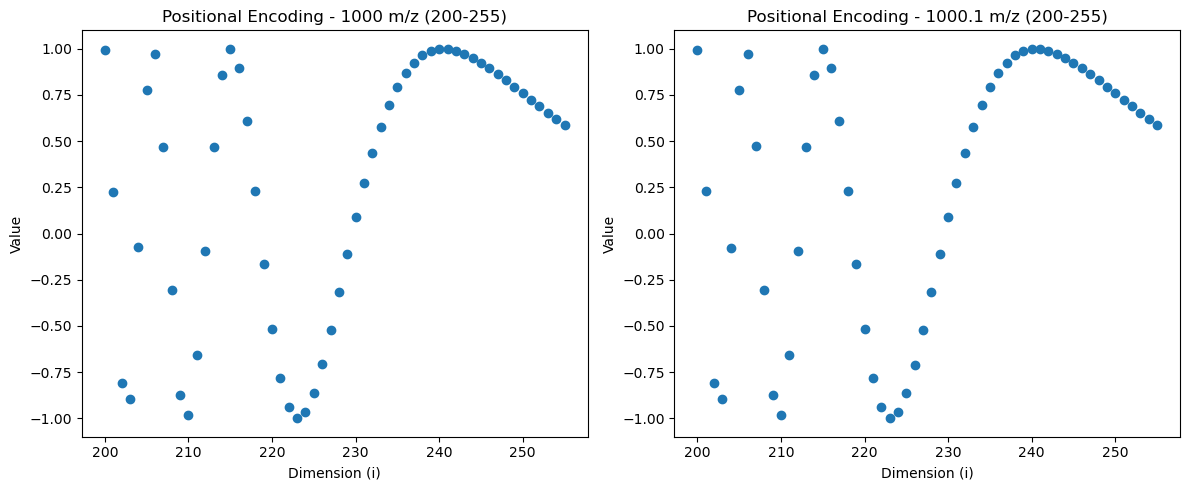

Cosine Similarity (1000 m/z vs 1000.1 m/z): 0.9999997415834381


In [61]:
# for encode_1 and encode_2, plot the values from 200 to 255
# and calculate the cosine similarity between the two
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(range(200, 256), encode_1[200:256])
plt.title("Positional Encoding - 1000 m/z (200-255)")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.subplot(1, 2, 2)
plt.scatter(range(200, 256), encode_2[200:256])
plt.title("Positional Encoding - 1000.1 m/z (200-255)")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.tight_layout()
plt.show()
from sklearn.metrics.pairwise import cosine_similarity

# Calculate cosine similarity between the two encodings
cosine_sim = cosine_similarity([encode_1[200:256]], [encode_2[200:256]])
print("Cosine Similarity (1000 m/z vs 1000.1 m/z):", cosine_sim[0][0])

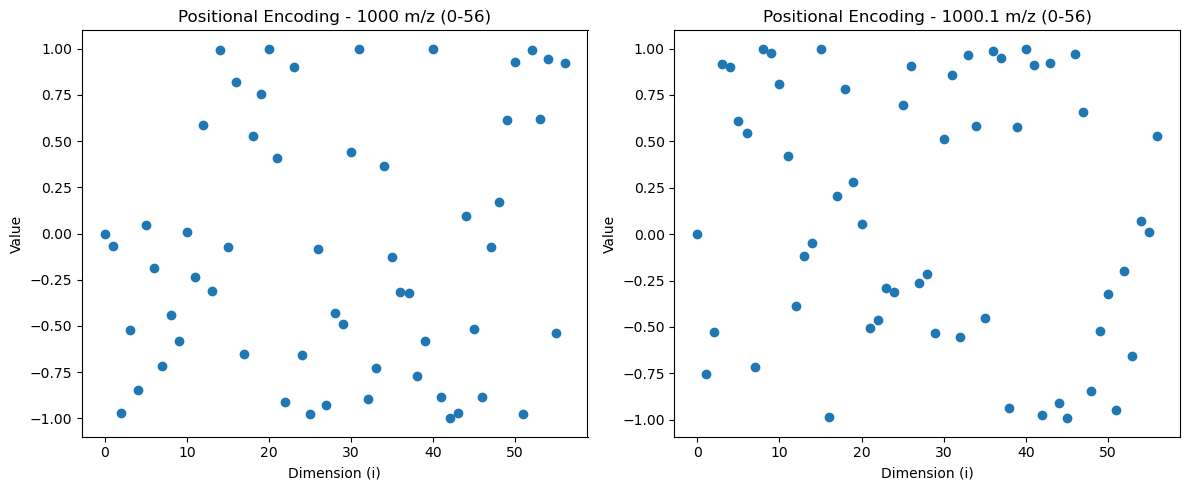

Cosine Similarity (1000 m/z vs 1000.1 m/z): -0.041003839526107366


In [62]:
# Repeat the above plots and calculations, but this time only consider the range from 0 to 56
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(range(0, 57), encode_1[0:57])
plt.title("Positional Encoding - 1000 m/z (0-56)")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.subplot(1, 2, 2)
plt.scatter(range(0, 57), encode_2[0:57])
plt.title("Positional Encoding - 1000.1 m/z (0-56)")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

# Calculate cosine similarity between the two encodings
cosine_sim = cosine_similarity([encode_1[0:57]], [encode_2[0:57]])
print("Cosine Similarity (1000 m/z vs 1000.1 m/z):", cosine_sim[0][0])